## 1. Load the Clustered Dataset

The clustering phase is now completed.
The dataset contains the patient clinical variables, the cluster assigned by K-Means, and the final `risk_category`.

In this notebook, we will use `risk_category` as the target variable for supervised classification.


In [19]:
import pandas as pd

df = pd.read_csv("../data/processed/diabetes_clustered.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster,risk_category
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627,50.0,2,Low Risk
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351,31.0,0,Low Risk
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672,32.0,2,Low Risk
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Low Risk
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,High Risk


In [20]:
df.shape

(768, 10)

In [21]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Cluster', 'risk_category'],
      dtype='str')

## 2. Define Features and Target

`X` contains the clinical variables used to make the prediction.

`y` contains the risk category that the model must predict.

We don't use `Cluster` as a feature because it was used to create `risk_category`.


In [22]:
clinical_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[clinical_columns]
y = df["risk_category"]

In [23]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351,31.0
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


In [24]:
y.head()

0     Low Risk
1     Low Risk
2     Low Risk
3     Low Risk
4    High Risk
Name: risk_category, dtype: str

## 3. Check Target Distribution

We check how many patients belong to each risk category.

This tells us whether the classes are balanced or imbalanced.


In [25]:
y.value_counts()

risk_category
Low Risk     568
High Risk    200
Name: count, dtype: int64

In [26]:
y.value_counts(normalize=True) * 100 # get percentage of each class

risk_category
Low Risk     73.958333
High Risk    26.041667
Name: proportion, dtype: float64

## 4. Train/Test Split

We split the dataset into training and testing data.

The model learns from the training data and is evaluated on the unseen test data.

`stratify=y` keeps a similar proportion of Low Risk and High Risk patients in both sets.


In [27]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #preserves the existing ratio
)

In [28]:
X_train.shape , X_test.shape

((614, 8), (154, 8))

In [29]:
y_train.value_counts()

risk_category
Low Risk     454
High Risk    160
Name: count, dtype: int64

In [30]:
y_test.value_counts()

risk_category
Low Risk     114
High Risk     40
Name: count, dtype: int64

## 6. Handle Class Imbalance with Scaling and SMOTE

The training dataset contains fewer **High Risk** patients than **Low Risk** patients.

Before applying SMOTE, we standardize the numerical features because SMOTE uses distances to find similar minority-class samples.

The steps are:

1. Standardize the training and test features using `StandardScaler`.
2. Apply `SMOTE` only to the scaled training data.
3. Keep the test data unchanged because it must represent unseen real data.
4. Check that the two classes are balanced after SMOTE.

SMOTE creates synthetic samples for the minority class instead of simply duplicating existing samples.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # if we use fit_transform here, data leakage

In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [33]:
y_train_smote.value_counts()

risk_category
Low Risk     454
High Risk    454
Name: count, dtype: int64

In [34]:
X_train_smote.shape, X_test_scaled.shape

((908, 8), (154, 8))

## 7. Train Classification Models

We train several classification algorithms using the same balanced training dataset.

The models used are:

* **Logistic Regression** — linear classification model.
* **KNN** — classifies a sample based on its nearest neighbors.
* **Random Forest** — combines multiple decision trees.
* **SVM** — finds a decision boundary that separates the classes.

All models are trained on the SMOTE-balanced training data and evaluated later on the same untouched test set.


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

### Create Models

In [36]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

### Train Models

In [37]:
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)

### 8.1 Logistic Regression — Make Predictions

The Logistic Regression model has already been trained using the SMOTE-balanced training data.

We now use the trained model to predict the risk category of the patients in the test set.

The test set contains 154 patients, so the model will produce 154 predictions.


In [38]:
logreg = models["Logistic Regression"]

y_pred_logreg = logreg.predict(X_test_scaled)

y_pred_logreg

array(['High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'High Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'High Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'High Risk',
       'High Risk', 'Low Risk', 'High Risk', 'Low Risk', 'High Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'High Risk', 'High Risk', 'High Risk',
       'High Risk', 'High Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low

In [39]:
len(y_pred_logreg)

154

In [41]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logreg
})

comparison.head(30)

,Actual,Predicted
0,High Risk,High Risk
1,High Risk,High Risk
2,Low Risk,Low Risk
3,Low Risk,Low Risk
4,High Risk,High Risk
5,Low Risk,Low Risk
6,Low Risk,Low Risk
7,Low Risk,Low Risk
8,Low Risk,Low Risk
9,Low Risk,Low Risk


### 8.2 Logistic Regression — Evaluation

We compare the predictions made by Logistic Regression with the actual test labels.

We use four main metrics:

* **Accuracy**: percentage of all predictions that are correct.
* **Precision**: among the patients predicted as High Risk, how many are actually High Risk.
* **Recall**: among the actual High Risk patients, how many were correctly detected.
* **F1-score**: combines precision and recall into a single metric.

We also use a confusion matrix to understand the types of errors made by the model.


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

precision_logreg = precision_score(
    y_test,
    y_pred_logreg,
    pos_label="High Risk"
)

recall_logreg = recall_score(
    y_test,
    y_pred_logreg,
    pos_label="High Risk"
)

f1_logreg = f1_score(
    y_test,
    y_pred_logreg,
    pos_label="High Risk"
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", accuracy_logreg)
print("Precision:", precision_logreg)
print("Recall   :", recall_logreg)
print("F1-score :", f1_logreg)

Logistic Regression
-------------------
Accuracy : 0.8571428571428571
Precision: 0.6551724137931034
Recall   : 0.95
F1-score : 0.7755102040816326


### 8.3 Logistic Regression — Confusion Matrix

The confusion matrix shows how the Logistic Regression model's predictions are distributed between correct and incorrect predictions.

It helps us identify:

* **True Positive (TP):** correctly predicted High Risk
* **True Negative (TN):** correctly predicted Low Risk
* **False Positive (FP):** predicted High Risk, but actually Low Risk
* **False Negative (FN):** predicted Low Risk, but actually High Risk


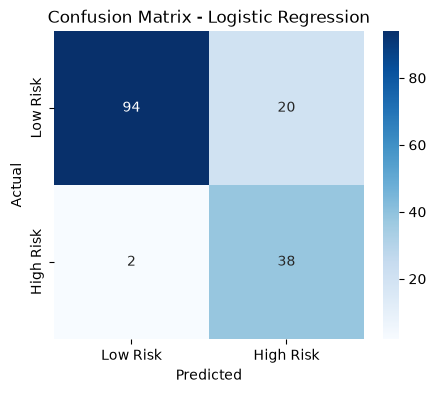

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_logreg = confusion_matrix(
    y_test,
    y_pred_logreg,
    labels=["Low Risk", "High Risk"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_logreg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### 8.3 Logistic Regression — Confusion Matrix

The confusion matrix helps us understand where the Logistic Regression model makes correct and incorrect predictions.

For this project, **High Risk** is considered the positive class and **Low Risk** is the negative class.

The confusion matrix is:

| Actual    | Predicted | Result      | Meaning                                                                                |
| --------- | --------- | ----------- | -------------------------------------------------------------------------------------- |
| Low Risk  | Low Risk  | **TN = 94** | 94 Low Risk patients were correctly classified.                                        |
| Low Risk  | High Risk | **FP = 20** | 20 Low Risk patients were incorrectly classified as High Risk. These are false alarms. |
| High Risk | Low Risk  | **FN = 2**  | 2 High Risk patients were incorrectly classified as Low Risk. These are missed cases.  |
| High Risk | High Risk | **TP = 38** | 38 High Risk patients were correctly classified.                                       |

#### Interpretation

* **TN = 94:** The model correctly identified 94 Low Risk patients.
* **FP = 20:** The model incorrectly classified 20 Low Risk patients as High Risk.
* **FN = 2:** The model missed 2 High Risk patients.
* **TP = 38:** The model correctly identified 38 High Risk patients.

The model correctly classified **132 out of 154 patients**.

The most important observation is that the model detected **38 out of 40 actual High Risk patients**, which explains the high **Recall of 95%**. However, it also produced **20 false positives**, which explains why the **Precision is lower at 65.52%**.
